In [ ]:
# Реализуйте высокочастотную фильтрацию на основе ядра Гаусса
# Реализуйте удаление периодического шума

Моё решение:

In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from skimage.feature import peak_local_max

img = cv.imread('periodic_noise.jpg', cv.IMREAD_GRAYSCALE)

# Реализуйте высокочастотную фильтрацию на основе ядра Гаусса
dft = cv.dft(np.float32(img), flags=cv.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

sigma = 30
rows, cols = img.shape
x, y = np.meshgrid(np.arange(0, cols, 1), np.arange(0, rows, 1))

gauss_mask = np.exp(-((x - (cols // 2)) ** 2 + (y - (rows // 2)) ** 2) / (2 * sigma ** 2))
mask = 1 - gauss_mask

dft_shift = dft_shift * mask[:, :, np.newaxis]

f_ishift = np.fft.ifftshift(dft_shift)
img_back = cv.idft(f_ishift)
img_back = cv.magnitude(img_back[:, :, 0], img_back[:, :, 1])

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Исходное изображение'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(img_back, cmap='gray')
plt.title('С высокочастотным фильтром'), plt.xticks([]), plt.yticks([])
plt.show()

# Реализуйте удаление периодического шума
dft = cv.dft(np.float32(img), flags=cv.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = 20 * np.log(cv.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]))
local_max = peak_local_max(magnitude_spectrum, min_distance=15, threshold_abs=200)

rows, cols = img.shape
mask = np.copy(dft_shift)
mask[:, :, :] = 1

for i in local_max:
    r = np.int32(((i[0] - rows // 2) ** 2 + (i[1] - cols // 2) ** 2) ** (1 / 2))
    cv.circle(mask, (rows // 2, cols // 2), r, (0, 0))

dft_shift = dft_shift * mask

f_ishift = np.fft.ifftshift(dft_shift)
img_back = cv.idft(f_ishift)
img_back = cv.magnitude(img_back[:, :, 0], img_back[:, :, 1])

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Исходное изображение'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(img_back, cmap='gray')
plt.title('Удаление периодического шума'), plt.xticks([]), plt.yticks([])
plt.show()


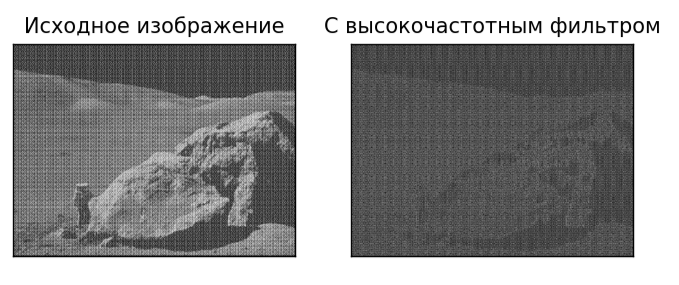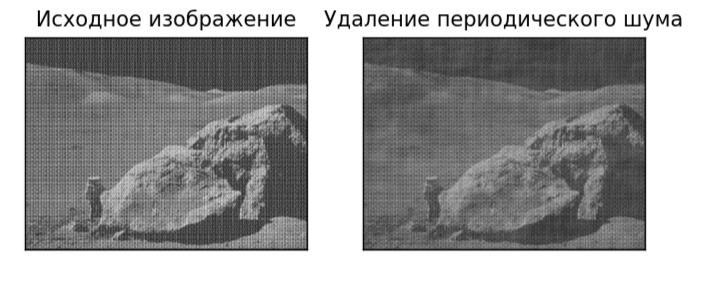